# **02 - Regularized linear models (OLS, Ridge, Lasso, Elastic Net)**

Linear models on `y = log1p(target)` for the Jeonse (deposit) and Wolse (monthly rent) tracks. Predictions are back-transformed with `expm1` and evaluated in original wones on TEST (2025).

**Variants**
- `*_static`: categorical features (`district_name`, `building_type`, `contract_type`, `renewal_right_used`) and numeric features (`log_area`, `floor`, `floor_missing`, `building_age`). No time feature.
- `*_time`: static features plus `t` (months since 2022-01) and `month_sin` / `month_cos`.
- `ridge_time_rich`: `ridge_time` plus the interactions district x building_type and log_area x building_type.
- `ols_static` is the reference without regularization; ridge, lasso and elastic net are tuned.

**Pipeline.** `OneHotEncoder(handle_unknown='ignore')` for categoricals, median imputation of `floor` (missing values are also flagged by `floor_missing`) and `StandardScaler` for numerics, all inside a scikit-learn `Pipeline`, so encoding and scaling are fit on TRAIN (or on the training part of each CV fold) only.

**Tuning.** Grid search on TRAIN with the 3-fold expanding-window CV of `rent_model.splits`; the score is WAPE on the original scale. TEST is used only for the final evaluation.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from rent_model import config
from rent_model.data import load_clean
from rent_model.features import build_features, build_target, inverse_target, select_track
from rent_model.io import save_run
from rent_model.linear import build_pipeline, feature_names, fit_predict, tune
from rent_model.metrics import all_metrics, wape
from rent_model.splits import expanding_window_folds, month_index, temporal_split

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 100
print('Random seed:', config.RANDOM_SEED)

Random seed: 42


## Data, splits and CV folds

In [2]:
df = load_clean()
SPECS = {  # model_id: (family, time variant, rich interactions)
    'ols_static': ('ols', False, False),
    'ridge_static': ('ridge', False, False),
    'lasso_static': ('lasso', False, False),
    'elasticnet_static': ('elasticnet', False, False),
    'ridge_time': ('ridge', True, False),
    'lasso_time': ('lasso', True, False),
    'elasticnet_time': ('elasticnet', True, False),
    'ridge_time_rich': ('ridge', True, True),
}
data = {}
for track in config.TRACKS:
    train, test = temporal_split(select_track(df, track))
    data[track] = dict(
        train=train, test=test,
        X_train=build_features(train, track, include_time=True), y_train=build_target(train, track),
        X_test=build_features(test, track, include_time=True), y_test_raw=test[config.TRACKS[track]['target']],
        folds=expanding_window_folds(train))
    folds = data[track]['folds']
    print(track, '| train', len(train), '| test', len(test), '| fold sizes (train, valid):',
          [(len(a), len(b)) for a, b in folds])

jeonse | train 138848 | test 37935 | fold sizes (train, valid): [(50327, 32062), (82389, 30026), (112415, 26433)]
wolse | train 152714 | test 57829 | fold sizes (train, valid): [(50860, 34709), (85569, 31839), (117408, 35306)]


## Hyperparameter tuning (3-fold expanding-window CV on TRAIN)

In [3]:
tuning = {}
for track in config.TRACKS:
    d = data[track]
    for model_id, (family, time, rich) in SPECS.items():
        if family == 'ols':
            continue
        best, table = tune(family, d['X_train'], d['y_train'], d['folds'], time=time, rich=rich)
        tuning[(track, model_id)] = (best, table)

cv_rows = []
for (track, model_id), (best, table) in tuning.items():
    top = table.iloc[0]
    cv_rows.append({'track': track, 'model_id': model_id,
                    **{k: v for k, v in best.items()},
                    'cv_wape_mean': top['cv_wape_mean'], 'cv_wape_std': top['cv_wape_std'],
                    'fold1': top['fold1'], 'fold2': top['fold2'], 'fold3': top['fold3']})
cv_summary = pd.DataFrame(cv_rows).set_index(['track', 'model_id'])
display(cv_summary)

alpha  cv_wape_mean  cv_wape_std   fold1   fold2   fold3  l1_ratio
track  model_id                                                                             
jeonse ridge_static      0.0100       23.0826       1.6386 21.5144 22.9498 24.7836       NaN
       lasso_static      0.0000       23.0843       1.6396 21.5146 22.9524 24.7859       NaN
       elasticnet_static 0.0000       23.0833       1.6390 21.5145 22.9508 24.7845    0.2000
       ridge_time        0.0100       23.8436       1.9795 21.5579 24.9749 24.9979       NaN
       lasso_time        0.0000       23.8441       1.9802 21.5575 24.9751 24.9996       NaN
       elasticnet_time   0.0000       23.8440       1.9797 21.5580 24.9753 24.9986    0.2000
       ridge_time_rich   1.0000       23.0074       1.8353 20.8889 24.1149 24.0185       NaN
wolse  ridge_static      0.0100       47.6356       2.8504 44.4773 48.4129 50.0167       NaN
       lasso_static      0.0000       47.6363       2.8509 44.4774 48.4135 50.0180       NaN
       elasticnet_static 0.0000       47.6359       2.8505 44.4773 48.4131 50.0171    0.2000
       ridge_time        0.0100       48.1603       2.0335 46.2153 47.9936 50.2721       NaN
       lasso_time        0.0003       48.1544       2.1006 46.1184 48.0305 50.3142       NaN
       elasticnet_time   0.0003       48.1559       2.0873 46.1381 48.0232 50.3063    0.8000
       ridge_time_rich   0.0100       45.9167       1.9829 43.8771 46.0355 47.8374       NaN

**Interpretation.** The time-series CV favours the rich variant in both tracks: mean CV WAPE is 23.01% for `ridge_time_rich` against 23.08% for `ridge_static` in Jeonse, and 45.92% against 47.64% in Wolse. The plain time variants are worse than the static ones in CV (23.84% vs 23.08% in Jeonse, 48.16% vs 47.64% in Wolse), so the single linear trend `t` does not help when it is validated forward in time. Fold-to-fold standard deviations are between 1.64 and 2.85 points, so differences among the three regularized families (below 0.01 points in every comparison) are noise. Most selected penalties sit at the lower edge of their grid (see the boundary check below): with 138,848 and 152,714 TRAIN rows and fewer than 150 columns, CV asks for almost no shrinkage and the regularized models converge to OLS.

Boundary check: a chosen value at the edge of its grid would suggest extending the grid.

In [4]:
from rent_model.linear import GRIDS
for (track, model_id), (best, _) in tuning.items():
    family = SPECS[model_id][0]
    edges = {k: (best[k] in (min(v), max(v))) for k, v in GRIDS[family].items()}
    print(f"{track:7s} {model_id:18s} {best}  at grid edge: {edges}")

jeonse  ridge_static       {'alpha': np.float64(0.01)}  at grid edge: {'alpha': True}
jeonse  lasso_static       {'alpha': np.float64(1e-05)}  at grid edge: {'alpha': True}
jeonse  elasticnet_static  {'alpha': np.float64(1e-05), 'l1_ratio': np.float64(0.2)}  at grid edge: {'alpha': True, 'l1_ratio': True}
jeonse  ridge_time         {'alpha': np.float64(0.01)}  at grid edge: {'alpha': True}
jeonse  lasso_time         {'alpha': np.float64(1e-05)}  at grid edge: {'alpha': True}
jeonse  elasticnet_time    {'alpha': np.float64(1e-05), 'l1_ratio': np.float64(0.2)}  at grid edge: {'alpha': True, 'l1_ratio': True}
jeonse  ridge_time_rich    {'alpha': np.float64(1.0)}  at grid edge: {'alpha': False}
wolse   ridge_static       {'alpha': np.float64(0.01)}  at grid edge: {'alpha': True}
wolse   lasso_static       {'alpha': np.float64(1e-05)}  at grid edge: {'alpha': True}
wolse   elasticnet_static  {'alpha': np.float64(1e-05), 'l1_ratio': np.float64(0.2)}  at grid edge: {'alpha': True, 'l1_ratio':

## Fit on TRAIN and evaluate on TEST (2025)

In [5]:
fitted, preds, rows = {}, {}, []
for track, spec in config.TRACKS.items():
    d = data[track]
    for model_id, (family, time, rich) in SPECS.items():
        params = {k: float(v) for k, v in tuning[(track, model_id)][0].items()} if family != 'ols' else {}
        pipe, pred = fit_predict(build_pipeline(family, time=time, rich=rich, **params),
                                 d['X_train'], d['y_train'], d['X_test'])
        fitted[(track, model_id)], preds[(track, model_id)] = pipe, pred
        cv_wape = float(tuning[(track, model_id)][1].loc[0, 'cv_wape_mean']) if family != 'ols' else None
        meta = {'family': family, 'time_variant': time, 'rich': rich, 'params': params,
                'cv_wape_mean': cv_wape, 'n_design_columns': len(feature_names(pipe)),
                'fit_period': '2022-01-01..2024-12-31', 'eval_period': '2025'}
        save_run(track, model_id, d['y_test_raw'], pred, meta=meta,
                 context=d['test'][['district_name', 'contract_date']])
        rows.append({'track': track, 'model_id': model_id,
                     **all_metrics(d['y_test_raw'].to_numpy(), pred)})
metrics = pd.DataFrame(rows)

# reference: best naive baseline saved by 01_baselines.ipynb
ref = {}
for track in config.TRACKS:
    last = json.loads((config.METRICS_DIR / f'{track}__baseline_district_type_area.json').read_text(encoding='utf-8'))[-1]
    ref[track] = last
cols = ['n', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'rmse_log', 'r2_log']
for track in config.TRACKS:
    table = metrics[metrics['track'] == track].set_index('model_id')[cols]
    table.loc['(ref) baseline_district_type_area'] = [ref[track][c] for c in cols]
    print(f'TEST metrics - {track}')
    display(table)

TEST metrics - jeonse


,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,
ols_static,"37,935.0000",24.3664,"10,982.1145",18.6255,-9.2051,-12.7540,0.3537,0.7808
ridge_static,"37,935.0000",24.3664,"10,982.1171",18.6254,-9.2051,-12.7540,0.3537,0.7808
lasso_static,"37,935.0000",24.3701,"10,983.7802",18.6236,-9.2060,-12.7603,0.3537,0.7808
elasticnet_static,"37,935.0000",24.3678,"10,982.7454",18.6265,-9.2049,-12.7564,0.3537,0.7808
ridge_time,"37,935.0000",24.0436,"10,836.6378",18.2974,-8.3812,-11.9167,0.3520,0.7829
lasso_time,"37,935.0000",24.0477,"10,838.5065",18.3047,-8.3874,-11.9239,0.3520,0.7828
elasticnet_time,"37,935.0000",24.0450,"10,837.2670",18.3034,-8.3813,-11.9191,0.3520,0.7828
ridge_time_rich,"37,935.0000",23.0944,"10,408.8488",17.9308,-8.2595,-10.6128,0.3428,0.7941
(ref) baseline_district_type_area,"37,935.0000",27.2510,"12,282.2552",20.3822,-4.7619,-10.2899,0.3909,0.7322


TEST metrics - wolse


,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,
ols_static,"57,829.0000",49.9662,37.4569,38.7759,-17.5402,-26.1871,0.7447,0.2473
ridge_static,"57,829.0000",49.9662,37.4569,38.7759,-17.5402,-26.1871,0.7447,0.2473
lasso_static,"57,829.0000",49.9684,37.4585,38.7762,-17.5382,-26.1915,0.7447,0.2472
elasticnet_static,"57,829.0000",49.9670,37.4574,38.7763,-17.5391,-26.1887,0.7447,0.2472
ridge_time,"57,829.0000",51.3471,38.4920,40.8782,-22.7534,-30.8606,0.7497,0.2372
lasso_time,"57,829.0000",51.3992,38.5311,40.8417,-22.7169,-30.9194,0.7500,0.2366
elasticnet_time,"57,829.0000",51.3909,38.5249,40.8437,-22.7379,-30.9132,0.7499,0.2367
ridge_time_rich,"57,829.0000",49.0983,36.8062,39.1765,-20.2776,-28.9682,0.7336,0.2695
(ref) baseline_district_type_area,"57,829.0000",46.9591,35.2026,32.5301,-7.4074,-14.5804,0.7641,0.2075


**Interpretation (Jeonse).** Regularization changes nothing: `ols_static`, `ridge_static`, `lasso_static` and `elasticnet_static` all have a TEST WAPE of 24.37%. Adding the time features gives 24.04% to 24.05%, and the interactions of `ridge_time_rich` give the best linear result, 23.09% (`r2_log` 0.7941), against 27.25% (`r2_log` 0.7322) for the best naive baseline. The bias stays negative: the median bias of `ridge_time_rich` is -8.26% (the baseline has -4.76%) and its aggregate bias is -10.61% (the baseline has -10.29%).

**Interpretation (Wolse).** The four static models are again identical (WAPE 49.97%) and the time variants are worse (51.35% to 51.40%). `ridge_time_rich` reaches 49.10%, which does not beat the naive `baseline_district_type_area` (46.96%) on WAPE or on median bias (-20.28% against -7.41%). On the log scale the linear model fits better (`rmse_log` 0.7336 against 0.7641, `r2_log` 0.2695 against 0.2075), so the weakness is the systematic underprediction on the original scale (aggregate bias -28.97%), not the ranking of contracts.

## Does the time variant fix the 2025 level shift?

In [6]:
pairs = [('ridge_static', 'ridge_time'), ('lasso_static', 'lasso_time'), ('elasticnet_static', 'elasticnet_time')]
shift = []
for track in config.TRACKS:
    m = metrics[metrics['track'] == track].set_index('model_id')
    for a, b in pairs:
        shift.append({'track': track, 'pair': f'{a} -> {b}',
                      'wape_static': m.loc[a, 'wape_pct'], 'wape_time': m.loc[b, 'wape_pct'],
                      'median_bias_static': m.loc[a, 'median_bias_pct'], 'median_bias_time': m.loc[b, 'median_bias_pct'],
                      'agg_bias_static': m.loc[a, 'aggregate_bias_pct'], 'agg_bias_time': m.loc[b, 'aggregate_bias_pct']})
display(pd.DataFrame(shift).set_index(['track', 'pair']))

for track in config.TRACKS:
    coef = pd.Series(fitted[(track, 'ridge_time')].named_steps['model'].coef_,
                     index=feature_names(fitted[(track, 'ridge_time')]))
    print(f'{track}: ridge_time coefficients (standardized numerics):', coef[['t', 'month_sin', 'month_cos']].round(4).to_dict())

quarter = lambda frame: frame['contract_date'].dt.quarter
for track in config.TRACKS:
    d = data[track]
    q = quarter(d['test'])
    calib = pd.DataFrame({'actual': d['y_test_raw'].groupby(q).median()})
    for model_id in ['ridge_static', 'ridge_time', 'ridge_time_rich']:
        calib[model_id] = pd.Series(preds[(track, model_id)], index=d['test'].index).groupby(q).median()
    print(f'Median by quarter of 2025 - {track}')
    display(calib)

wape_static  wape_time  median_bias_static  median_bias_time  agg_bias_static  agg_bias_time
track  pair                                                                                                                              
jeonse ridge_static -> ridge_time                24.3664    24.0436             -9.2051           -8.3812         -12.7540       -11.9167
       lasso_static -> lasso_time                24.3701    24.0477             -9.2060           -8.3874         -12.7603       -11.9239
       elasticnet_static -> elasticnet_time      24.3678    24.0450             -9.2049           -8.3813         -12.7564       -11.9191
wolse  ridge_static -> ridge_time                49.9662    51.3471            -17.5402          -22.7534         -26.1871       -30.8606
       lasso_static -> lasso_time                49.9684    51.3992            -17.5382          -22.7169         -26.1915       -30.9194
       elasticnet_static -> elasticnet_time      49.9670    51.3909            -17.5391          -22.7379         -26.1887       -30.9132

jeonse: ridge_time coefficients (standardized numerics): {'t': 0.0042, 'month_sin': -0.0071, 'month_cos': 0.0037}
wolse: ridge_time coefficients (standardized numerics): {'t': -0.0291, 'month_sin': -0.0119, 'month_cos': 0.0145}
Median by quarter of 2025 - jeonse


,actual,ridge_static,ridge_time,ridge_time_rich
contract_date,,,,
1,"35,000.0000","33,781.9877","33,863.5769","32,345.5712"
2,"34,500.0000","33,111.9041","33,159.9512","31,822.1634"
3,"36,500.0000","34,227.8198","34,804.4397","33,468.3431"
4,"38,825.0000","35,486.9922","36,251.7432","35,090.6161"


Median by quarter of 2025 - wolse


,actual,ridge_static,ridge_time,ridge_time_rich
contract_date,,,,
1,55.0000,47.6136,45.0530,44.3580
2,55.0000,49.3352,45.3717,43.9392
3,58.0000,48.7953,45.7589,44.8769
4,57.0000,49.4800,46.9335,45.5704


**Interpretation.** The time variant does not fix the 2025 level shift. In Jeonse it helps slightly: for ridge, WAPE goes from 24.37% to 24.04%, median bias from -9.21% to -8.38% and aggregate bias from -12.75% to -11.92%; the fitted coefficient of `t` is 0.0042, and in Q4 the actual median is 38,825 while `ridge_time` predicts 36,252 (`ridge_static` 35,487). In Wolse it hurts: WAPE rises from 49.97% to 51.35%, median bias goes from -17.54% to -22.75% and aggregate bias from -26.19% to -30.86%. The coefficient of `t` is -0.0291, i.e. the trend learned in 2022-2024 is negative, while the actual quarterly median in 2025 is 55, 55, 58 and 57 and `ridge_time` predicts 45.05 to 46.93. A linear trend fitted on three years extrapolates a past slope and does not capture the 2025 level; Lasso and Elastic Net behave like Ridge.

## Best model per track: coefficients

In [7]:
best_id = {}
for track in config.TRACKS:
    m = metrics[metrics['track'] == track].set_index('model_id')
    best_id[track] = m['wape_pct'].idxmin()
    pipe = fitted[(track, best_id[track])]
    coefs = pd.Series(pipe.named_steps['model'].coef_, index=feature_names(pipe))
    top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)
    print(f"{track}: best model by TEST WAPE = {best_id[track]} (WAPE {m.loc[best_id[track], 'wape_pct']:.2f}%); "
          f"non-zero coefficients: {(coefs != 0).sum()} of {len(coefs)}")
    display(top.rename('coefficient (log1p scale; numerics standardized)').to_frame())

jeonse: best model by TEST WAPE = ridge_time_rich (WAPE 23.09%); non-zero coefficients: 145 of 145


,coefficient (log1p scale; numerics standardized)
building_type_Row house / Villa (multi-unit),0.5680
building_type_Apartment,-0.5165
log_area,0.4139
log_area x Apartment,0.3844
log_area x Row house / Villa (multi-unit),-0.3134
district_name_Gangnam-gu,0.2793
district_name_Seocho-gu,0.2529
district_name_Dobong-gu,-0.2393
district_name_Nowon-gu,-0.2050
building_age,-0.1909


wolse: best model by TEST WAPE = ridge_time_rich (WAPE 49.10%); non-zero coefficients: 145 of 145


,coefficient (log1p scale; numerics standardized)
building_type_Apartment,-1.1606
building_type_Row house / Villa (multi-unit),0.7971
log_area x Apartment,0.6523
log_area x Detached / Multi-household house,-0.4015
floor_missing,0.3621
log_area x Row house / Villa (multi-unit),-0.3307
district_x_type_Guro-gu | Apartment,-0.3049
district_x_type_Jungnang-gu | Apartment,-0.2770
log_area,0.2732
contract_type_New,0.2478


**Interpretation (Jeonse).** The best model is `ridge_time_rich`; Ridge keeps all 145 coefficients non-zero, so no feature selection takes place. The largest effects are building type (Row house / Villa +0.5680, Apartment -0.5165), log area (+0.4139, with the interactions +0.3844 for Apartment and -0.3134 for Row house / Villa), district (Gangnam-gu +0.2793, Seocho-gu +0.2529, Dobong-gu -0.2393) and `building_age` (-0.1909 per standard deviation). One-hot columns and their interactions are collinear, so individual coefficients should be read jointly and not as isolated effects.

**Interpretation (Wolse).** The best model is also `ridge_time_rich`, with 145 non-zero coefficients. Building type has the largest coefficients (Apartment -1.1606, Row house / Villa +0.7971) together with the area slope of Apartment (+0.6523). `floor_missing` (+0.3621) and `contract_type_New` (+0.2478) are also relevant, and Gangnam-gu has +0.2461. As in Jeonse, the interaction columns are collinear with the main effects.

## Residual diagnostics (log scale, TEST, best model)

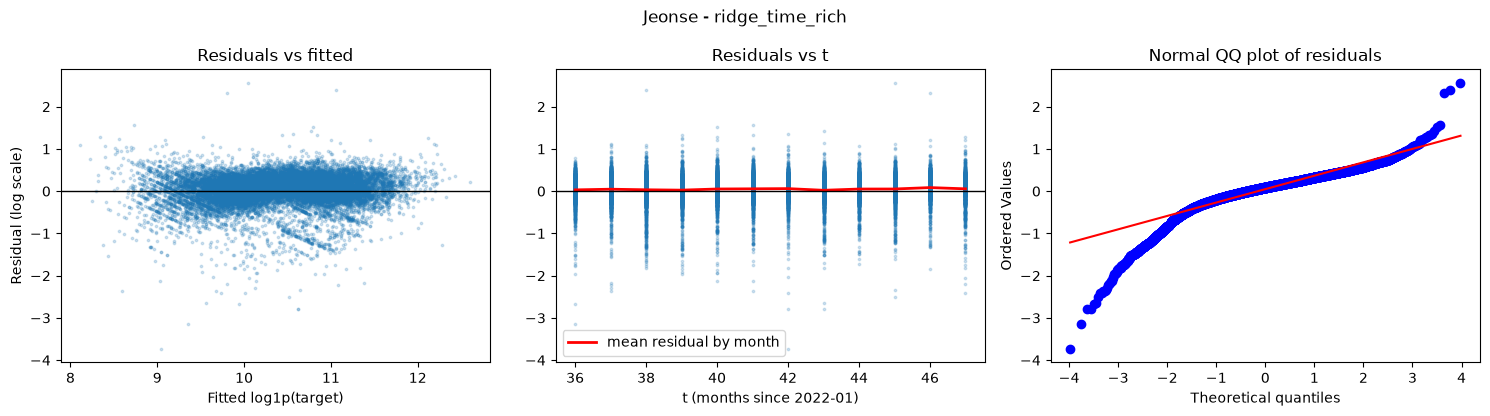

jeonse: residual mean 0.0462, median 0.0862, std 0.3397


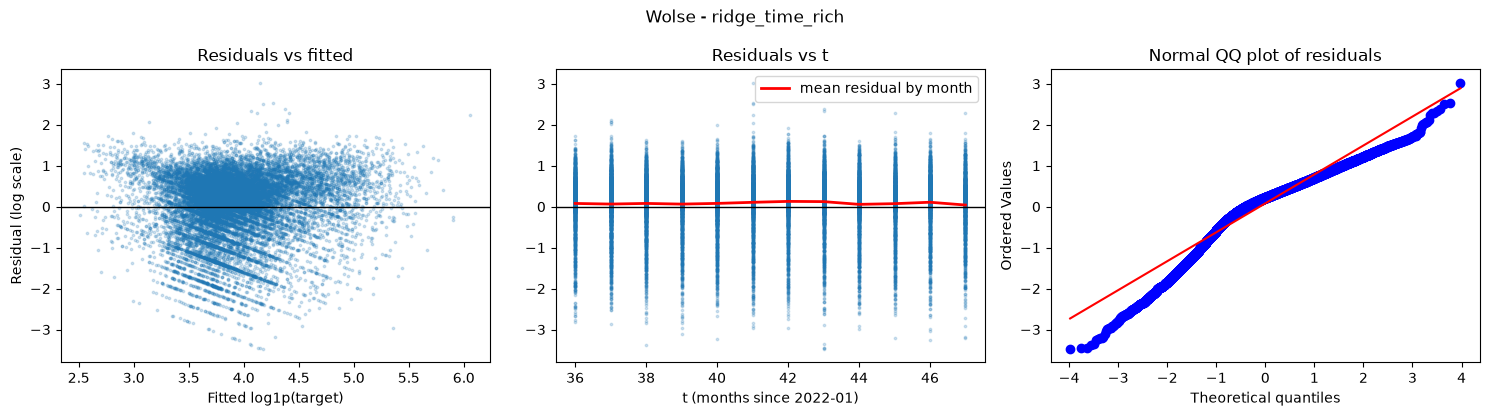

wolse: residual mean 0.0838, median 0.2222, std 0.7288


In [8]:
rng = np.random.default_rng(config.RANDOM_SEED)
for track in config.TRACKS:
    d = data[track]
    pred = preds[(track, best_id[track])]
    fitted_log = np.log1p(pred)
    resid = np.log1p(d['y_test_raw'].to_numpy()) - fitted_log
    t_idx = month_index(d['test']['contract_date'])
    sample = rng.choice(len(resid), size=min(20_000, len(resid)), replace=False)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    axes[0].scatter(fitted_log[sample], resid[sample], s=3, alpha=0.2)
    axes[0].axhline(0, color='black', lw=1)
    axes[0].set(xlabel='Fitted log1p(target)', ylabel='Residual (log scale)', title='Residuals vs fitted')
    axes[1].scatter(t_idx[sample], resid[sample], s=3, alpha=0.2)
    mean_by_t = pd.Series(resid).groupby(t_idx).mean()
    axes[1].plot(mean_by_t.index, mean_by_t.values, color='red', lw=2, label='mean residual by month')
    axes[1].axhline(0, color='black', lw=1)
    axes[1].set(xlabel='t (months since 2022-01)', title='Residuals vs t'); axes[1].legend()
    stats.probplot(resid[sample], dist='norm', plot=axes[2])
    axes[2].set_title('Normal QQ plot of residuals')
    fig.suptitle(f'{track.capitalize()} - {best_id[track]}')
    plt.tight_layout(); plt.show()
    print(f"{track}: residual mean {resid.mean():.4f}, median {np.median(resid):.4f}, std {resid.std():.4f}")

**Interpretation (Jeonse).** Residuals are defined as log1p(actual) minus log1p(prediction). Their mean is 0.0462 and their median 0.0862, so the model tends to predict below the actual value on TEST, consistent with the negative bias. The standard deviation is 0.3397.

**Interpretation (Wolse).** The mean residual is 0.0838 and the median 0.2222, a larger positive offset than in Jeonse (actual values above the predictions), and the standard deviation is 0.7288, about twice that of Jeonse (0.3397). Most of the error variance remains unexplained by district, type, area and floor.

## Error by building_type and district (best model)

In [9]:
for track in config.TRACKS:
    d = data[track]; test = d['test']; target = config.TRACKS[track]['target']
    frame = test.assign(pred=preds[(track, best_id[track])])
    by_type = frame.groupby('building_type').apply(
        lambda g: pd.Series({'n_test': len(g), 'wape_pct': wape(g[target], g['pred']),
                             'median_bias_pct': float(np.median((g['pred'] - g[target]) / g[target]) * 100)}),
        include_groups=False).astype({'n_test': int})
    by_district = frame.groupby('district_name').apply(
        lambda g: pd.Series({'n_test': len(g), 'wape_pct': wape(g[target], g['pred'])}),
        include_groups=False).sort_values('wape_pct').astype({'n_test': int})
    print(f'{track} - {best_id[track]}: by building_type'); display(by_type)
    print('Lowest WAPE (five best districts)'); display(by_district.head(5))
    print('Highest WAPE (five worst districts)'); display(by_district.tail(5).iloc[::-1])

jeonse - ridge_time_rich: by building_type


,n_test,wape_pct,median_bias_pct
building_type,,,
Apartment,22645,23.4337,-11.2958
Detached / Multi-household house,3977,33.3251,-5.1452
Officetel,3369,16.9207,-5.2576
Row house / Villa (multi-unit),7944,20.2536,-2.4898


Lowest WAPE (five best districts)


,n_test,wape_pct
district_name,,
Jung-gu,598,17.2505
Dobong-gu,816,17.8490
Dongdaemun-gu,1463,17.9074
Seongbuk-gu,1347,18.0303
Geumcheon-gu,713,18.1213


Highest WAPE (five worst districts)


...

,n_test,wape_pct,median_bias_pct
building_type,,,
Apartment,17911,55.4725,-29.1923
Detached / Multi-household house,17711,32.9082,-14.2341
Officetel,10300,47.4231,-23.6427
Row house / Villa (multi-unit),11907,54.1157,-22.8456


Lowest WAPE (five best districts)


,n_test,wape_pct
district_name,,
Dobong-gu,977,35.9791
Gangbuk-gu,1157,39.1117
Gwanak-gu,3924,39.7928
Nowon-gu,1885,40.8883
Gwangjin-gu,2977,41.4882


Highest WAPE (five worst districts)


,n_test,wape_pct
district_name,,
Yongsan-gu,1233,59.3412
Songpa-gu,4660,57.2775
Seocho-gu,2686,56.5515
Gangnam-gu,3643,52.4937
Yeongdeungpo-gu,2934,52.0972


**Interpretation (Jeonse).** By building type, Officetel has the lowest WAPE (16.92%) and Detached / Multi-household house the highest (33.32%); Apartment, the largest group (22,645 test rows), has 23.43% and a median bias of -11.30%. By district, WAPE ranges from 17.25% (Jung-gu) to 32.35% (Yangcheon-gu).

**Interpretation (Wolse).** Detached / Multi-household house has the lowest WAPE (32.91%) while Apartment (55.47%) and Row house / Villa (54.12%) are the highest; the median bias is negative in every type, from -14.23% (Detached / Multi-household house) to -29.19% (Apartment). By district, WAPE ranges from 35.98% (Dobong-gu) to 59.34% (Yongsan-gu).

## Summary

In [10]:
summary = metrics.pivot(index='model_id', columns='track', values=['wape_pct', 'median_bias_pct']).loc[list(SPECS)]
display(summary)

wape_pct         median_bias_pct         
track               jeonse   wolse          jeonse    wolse
model_id                                                   
ols_static         24.3664 49.9662         -9.2051 -17.5402
ridge_static       24.3664 49.9662         -9.2051 -17.5402
lasso_static       24.3701 49.9684         -9.2060 -17.5382
elasticnet_static  24.3678 49.9670         -9.2049 -17.5391
ridge_time         24.0436 51.3471         -8.3812 -22.7534
lasso_time         24.0477 51.3992         -8.3874 -22.7169
elasticnet_time    24.0450 51.3909         -8.3813 -22.7379
ridge_time_rich    23.0944 49.0983         -8.2595 -20.2776

## Conclusion

- **Regularization is irrelevant here.** OLS, Ridge, Lasso and Elastic Net give practically the same TEST WAPE in each variant (24.37% in Jeonse and 49.97% in Wolse for the static ones); the sample is large relative to the number of features.
- **Interactions help, a linear trend does not.** `ridge_time_rich` is the best linear model in both tracks (23.09% Jeonse, 49.10% Wolse), while adding only `t` and seasonality improves Jeonse slightly and worsens Wolse.
- **Against the baselines.** In Jeonse the linear model beats the best naive baseline (23.09% against 27.25%). In Wolse it does not (49.10% against 46.96%) and its median bias is much larger, so Wolse needs models with a better handling of the level and of non-linear structure.